# 🔬 Soil GSD: Elegant EDA & Scale Insights

### Competition Overview
The goal of this competition is to predict the **Grain Size Distribution (GSD)** of soil based on photographs. This is a unique **Distribution Regression** task: for each image, we need to predict the cumulative percentage of soil fractions across 11 different sieve sizes (ranging from 0.002 mm to 200 mm).

Crucially, we are provided with a `ppm.csv` (Pixels Per Millimeter) file. This file provides the spatial scale for different device cameras, which is essential for translating pixel dimensions into physical, real-world measurements.

---

## 1. Setup & Dependencies

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings

warnings.filterwarnings("ignore")

# Visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.size": 12, "axes.labelsize": 14, "figure.titlesize": 16})

# Define data paths
DATA_DIR = "/kaggle/input/competitions/soil-grain-size-from-photos"  # Adjust if running locally
TRAIN_LABELS_PATH = os.path.join(DATA_DIR, "Training_labels_without_H374.csv")
PPM_PATH = os.path.join(DATA_DIR, "ppm.csv")
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "Training-All_Photos_without_H374")
TEST_IMG_DIR = os.path.join(DATA_DIR, "Test_All_Photos")

## 2. Loading and Previewing Tabular Data

In [2]:
# Load metadata and targets
df_labels = pd.read_csv(TRAIN_LABELS_PATH)
df_ppm = pd.read_csv(PPM_PATH)

print(f"Number of training samples: {df_labels.shape[0]}")
print(f"Number of target size fractions: {df_labels.shape[1] - 1}")

# Display first few rows for Kaggle preview
display(df_labels.head())
display(df_ppm.head())

Number of training samples: 25
Number of target size fractions: 11


,sample_id,0.002,0.0063,0.02,0.063,0.2,0.63,2,6.3,20,63,200
0,F827,9.4904,19.3892,47.6257,89.5554,99.8965,99.9896,100.0000,100.0000,100.0000,100.0000,100.0
1,G190,5.2076,10.2425,23.7537,50.3113,75.8311,85.7233,90.9898,94.8969,98.5814,100.0000,100.0
2,H030,6.7833,10.9091,19.0599,37.3235,66.8349,96.4965,97.9530,99.5691,100.0000,100.0000,100.0
3,H031,1.8556,5.5638,11.4945,19.1022,25.8591,39.6389,50.5450,65.2738,81.4215,94.7783,100.0
4,H037,0.9320,6.4500,16.3216,27.8019,34.6629,46.3652,62.7168,79.0523,89.7830,100.0000,100.0


,phone,camera,width,height,ppm
0,iPhone 14,iPhone 14,4032,3024,13.942
1,iPhone 16,iPhone 16,5712,4284,19.525
2,Motorola Edge,motorola edge 20,4000,1800,11.492
3,Samsung A52,SM-A525F,9248,6936,26.330


## Target Variable Analysis (Grain Size Distribution Curves)
Since the target columns represent the cumulative percentage of soil passing through a sieve, we can plot them as standard geotechnical grading curves using a logarithmic scale for grain sizes.

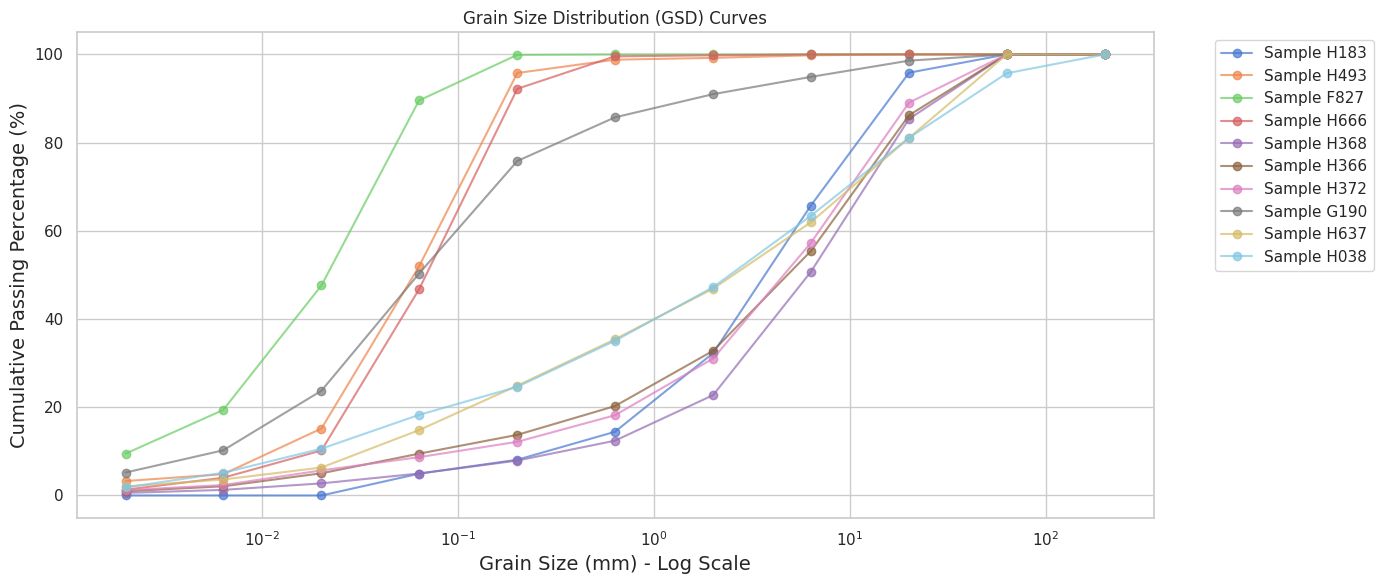

In [3]:
# Extract size columns and convert them to floats for plotting
size_columns = [col for col in df_labels.columns if col != "sample_id"]
sizes_num = [float(col) for col in size_columns]

plt.figure(figsize=(14, 6))

# Plot cumulative GSD curves for 10 random samples
sampled_df = df_labels.sample(10, random_state=42)
for idx, row in sampled_df.iterrows():
    plt.plot(
        sizes_num,
        row[size_columns].values,
        marker="o",
        alpha=0.7,
        label=f"Sample {row['sample_id']}",
    )

plt.xscale("log")  # Grain size distributions are traditionally log-scaled
plt.xlabel("Grain Size (mm) - Log Scale")
plt.ylabel("Cumulative Passing Percentage (%)")
plt.title("Grain Size Distribution (GSD) Curves")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

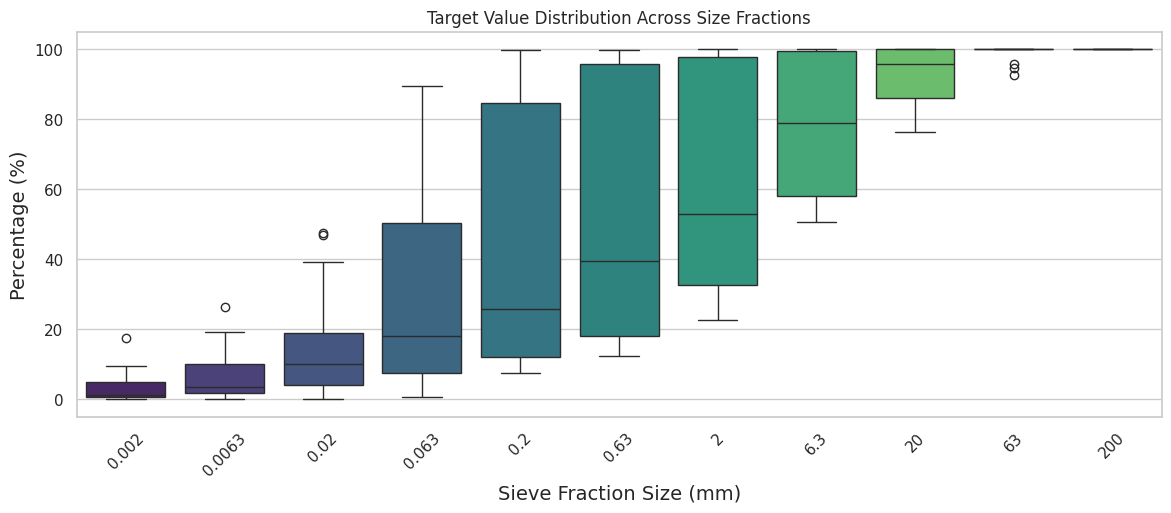

In [4]:
# Distribution analysis via Boxplot
plt.figure(figsize=(14, 5))
sns.boxplot(data=df_labels[size_columns], palette="viridis")
plt.title("Target Value Distribution Across Size Fractions")
plt.xlabel("Sieve Fraction Size (mm)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

## 4. Camera & Scale Analysis (ppm.csv)
Understanding the ppm (Pixels Per Millimeter) distribution is vital, as it tells us how much physical space a single pixel covers across different devices.

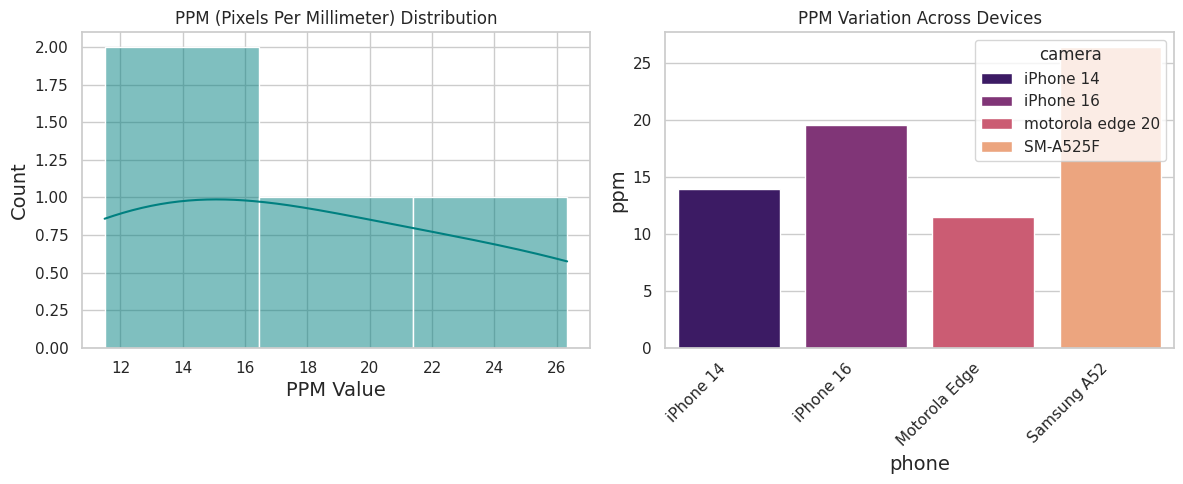

In [5]:
plt.figure(figsize=(12, 5))

# PPM Distribution Histogram
plt.subplot(1, 2, 1)
sns.histplot(df_ppm["ppm"], kde=True, color="teal")
plt.title("PPM (Pixels Per Millimeter) Distribution")
plt.xlabel("PPM Value")

# PPM by Phone and Camera Type
plt.subplot(1, 2, 2)
sns.barplot(data=df_ppm, x="phone", y="ppm", hue="camera", palette="magma")
plt.title("PPM Variation Across Devices")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 5. Co-Visualizing Images and GSD Curves
Let's build a function that pairs a soil photo with its corresponding GSD curve. This helps us visually verify whether images with coarser visible grains actually shift the grading curve to the right.

In [6]:
import os

print("Directory exists:", os.path.exists(TRAIN_IMG_DIR))
if os.path.exists(TRAIN_IMG_DIR):
    items = os.listdir(TRAIN_IMG_DIR)
    print(f"Total items found: {len(items)}")
    print("First 10 items:", items[:10])

Directory exists: True
Total items found: 1
First 10 items: ['Training-All_Photos_without_H374']


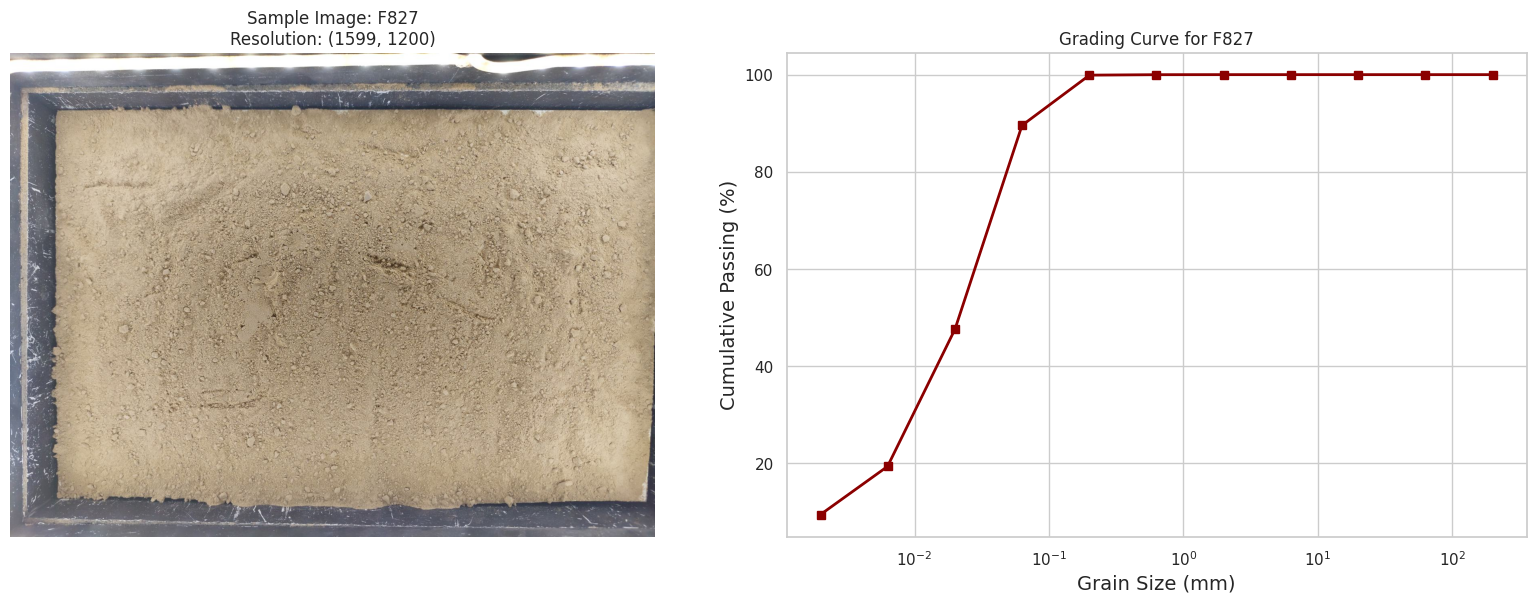

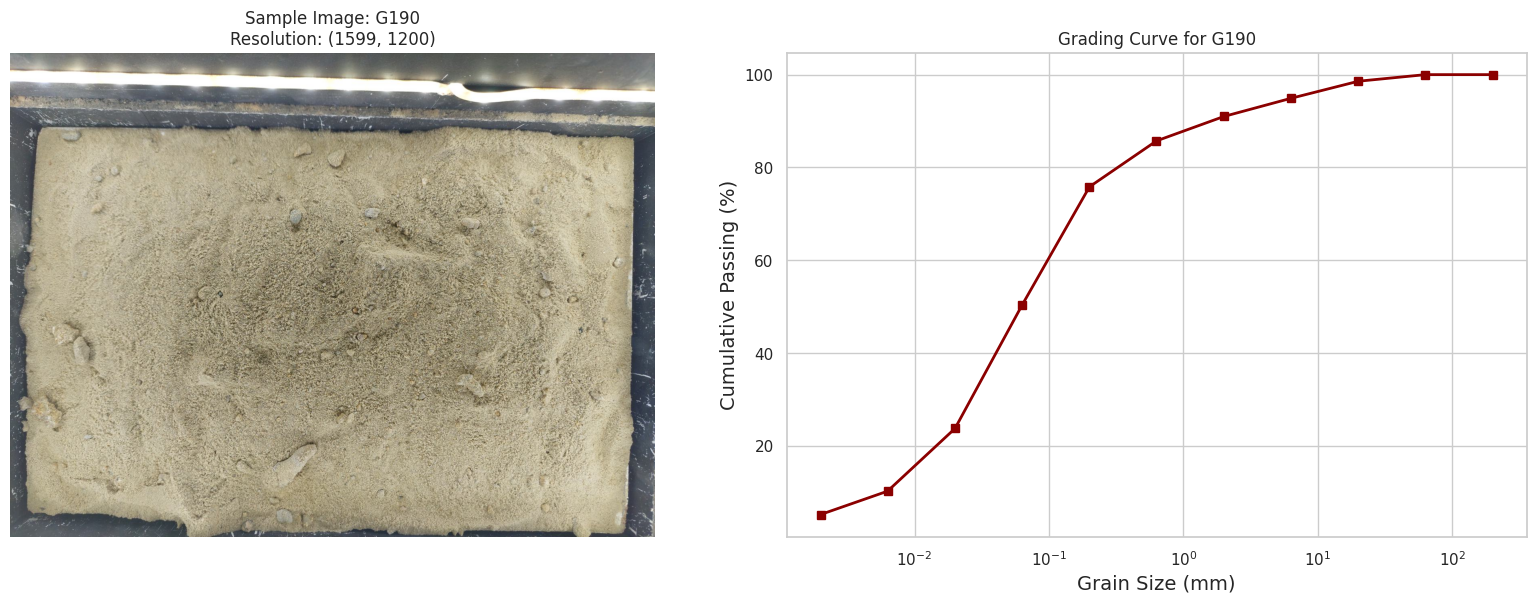

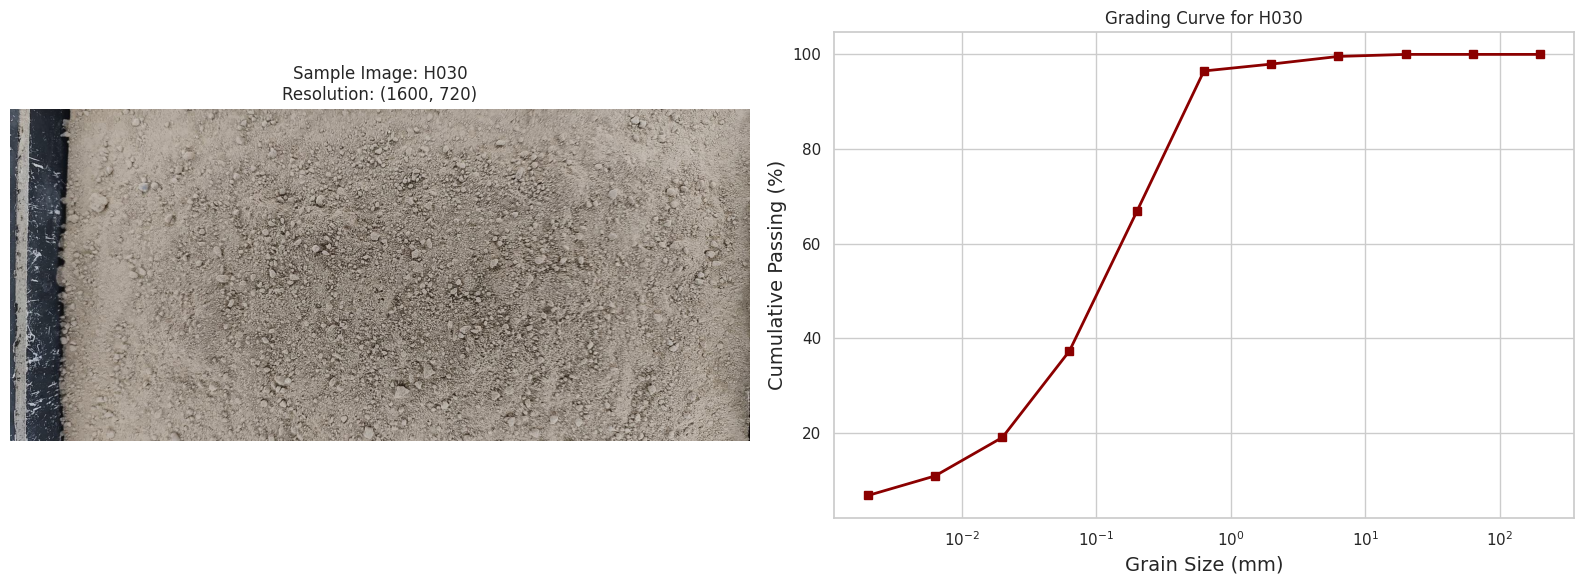

In [7]:
def plot_sample_and_distribution(sample_id):
    # Robust search: recursive (handles nested folders) and case-insensitive
    img_path = None
    search_name = str(sample_id).lower()

    # Walk through the directory to find the file regardless of case or subfolders
    for root, _, files in os.walk(TRAIN_IMG_DIR):
        for file in files:
            if search_name in file.lower():
                img_path = os.path.join(root, file)
                break
        if img_path:
            break

    if not img_path:
        print(f"Image for sample {sample_id} not found.")
        return

    # Load image
    img = Image.open(img_path)

    # Fetch target row
    sample_data = df_labels[df_labels["sample_id"] == sample_id].iloc[0]

    # Subplot generation
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Image visualization
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"Sample Image: {sample_id}\nResolution: {img.size}")

    # 2. GSD Curve plotting
    axes[1].plot(
        sizes_num, sample_data[size_columns].values, marker="s", color="darkred", lw=2
    )
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Grain Size (mm)")
    axes[1].set_ylabel("Cumulative Passing (%)")
    axes[1].set_title(f"Grading Curve for {sample_id}")

    plt.tight_layout()
    plt.show()


# Display the first 3 samples from the dataset
for s_id in df_labels["sample_id"].head(3):
    plot_sample_and_distribution(s_id)

## 6. Color Channel & Basic Texture Profiling
Providing a quick look at pixel intensity distributions is a great addition for a public EDA, nudging readers toward texture-based feature extraction.

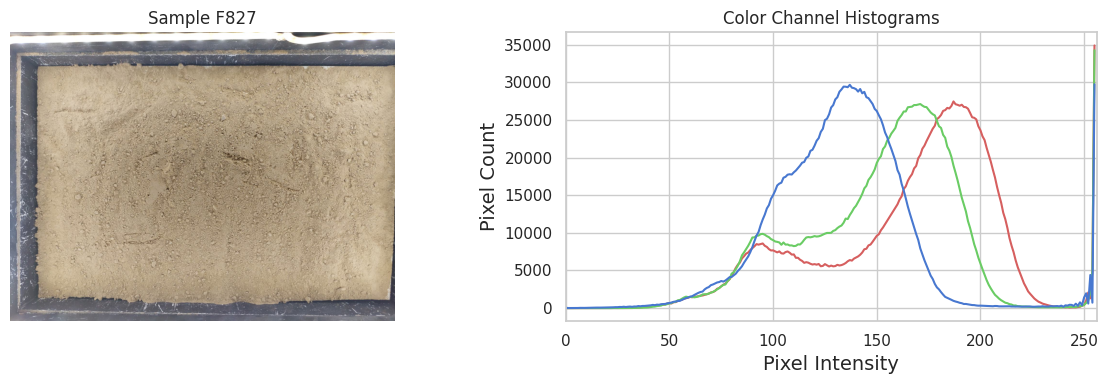

In [8]:
def plot_color_histograms(sample_id):
    # Robust search: recursive and case-insensitive (matches cell 5 logic)
    img_path = None
    search_name = str(sample_id).lower()

    for root, _, files in os.walk(TRAIN_IMG_DIR):
        for file in files:
            if search_name in file.lower():
                img_path = os.path.join(root, file)
                break
        if img_path:
            break

    if not img_path:
        print(f"Image for sample {sample_id} not found.")
        return

    # Load and convert image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    colors = ("r", "g", "b")
    plt.figure(figsize=(12, 4))

    # 1. Image visualization
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Sample {sample_id}")

    # 2. Histogram generation
    plt.subplot(1, 2, 2)
    for i, color in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=color)
        plt.xlim([0, 256])
    plt.title("Color Channel Histograms")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Pixel Count")

    plt.tight_layout()
    plt.show()


# Run the function for the first sample
plot_color_histograms(df_labels["sample_id"].iloc[0])

## 7. The Global Soil Profile (Dataset-Wide GSD)
Instead of looking at individual samples, let's visualize the average grain size distribution curve across the entire training dataset, including the variance (standard deviation bands). This helps us understand the dominant soil types in this competition.

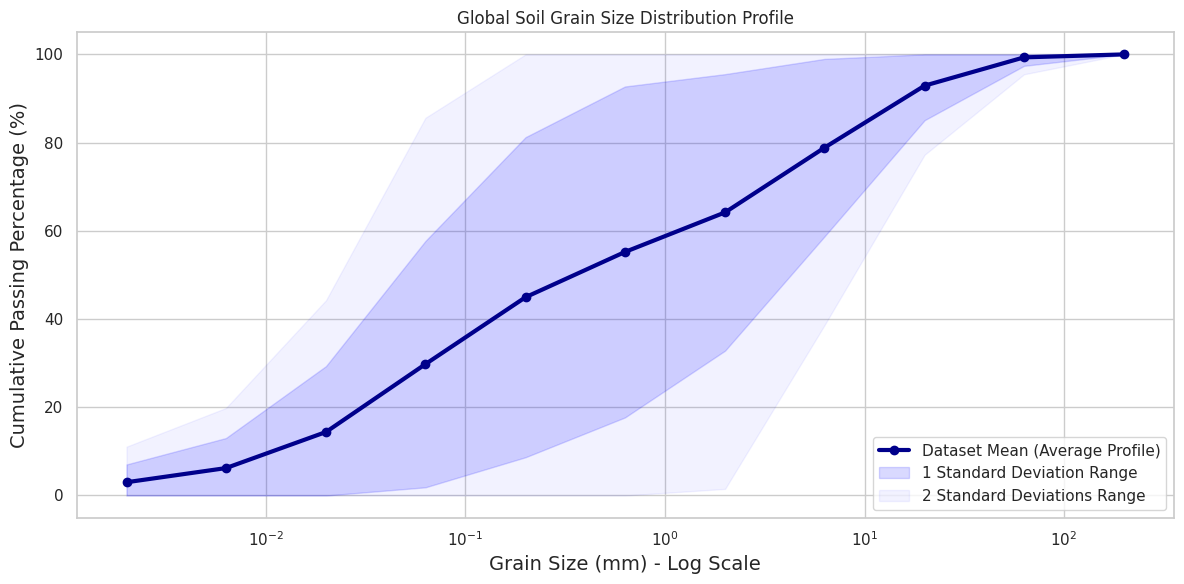

In [9]:
# Calculate mean and standard deviation for each fraction
mean_gsd = df_labels[size_columns].mean().values
std_gsd = df_labels[size_columns].std().values

plt.figure(figsize=(12, 6))

# Plot mean curve
plt.plot(
    sizes_num,
    mean_gsd,
    color="darkblue",
    lw=3,
    marker="o",
    label="Dataset Mean (Average Profile)",
)

# Fill standard deviation areas
plt.fill_between(
    sizes_num,
    np.clip(mean_gsd - std_gsd, 0, 100),
    np.clip(mean_gsd + std_gsd, 0, 100),
    color="blue",
    alpha=0.15,
    label="1 Standard Deviation Range",
)
plt.fill_between(
    sizes_num,
    np.clip(mean_gsd - 2 * std_gsd, 0, 100),
    np.clip(mean_gsd + 2 * std_gsd, 0, 100),
    color="blue",
    alpha=0.05,
    label="2 Standard Deviations Range",
)

plt.xscale("log")
plt.xlabel("Grain Size (mm) - Log Scale")
plt.ylabel("Cumulative Passing Percentage (%)")
plt.title("Global Soil Grain Size Distribution Profile")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Target Inter-Correlation Analysis
Since the targets represent cumulative percentages, adjacent sieve fractions are heavily dependent on each other. Let's look at the correlation matrix to understand the structural constraint of the target variables.

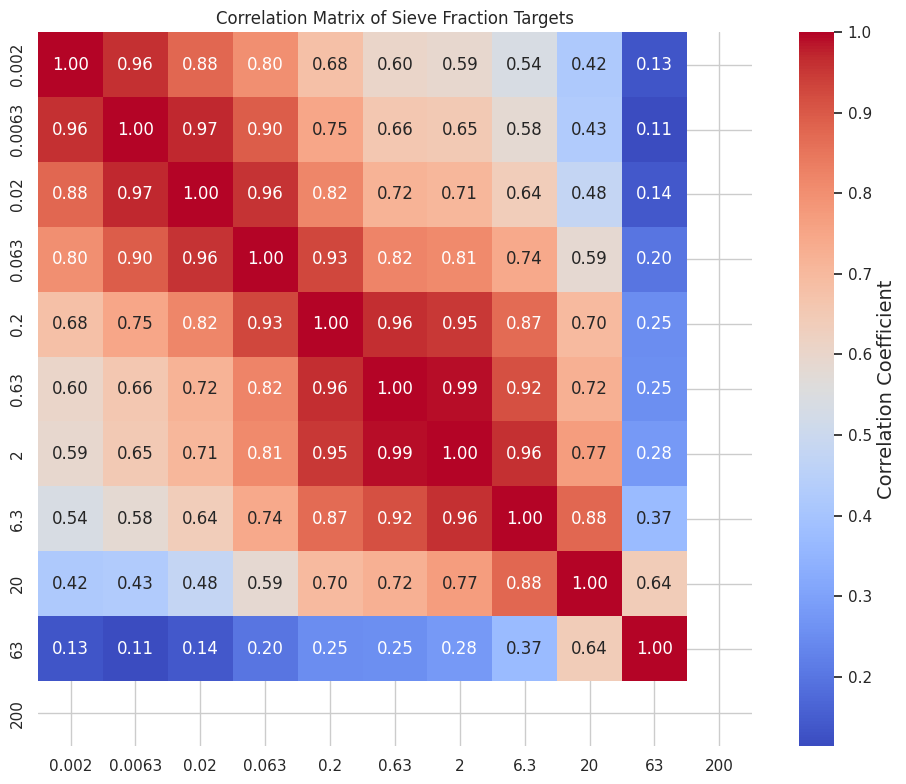

In [10]:
# Compute correlation matrix for the 11 target columns
target_corr = df_labels[size_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"label": "Correlation Coefficient"},
)
plt.title("Correlation Matrix of Sieve Fraction Targets")
plt.tight_layout()
plt.show()

## 9. Computer Vision Insight: Grain Boundary Detection (Edges)
Can traditional CV features capture grain size differences? Let's apply a **Canny Edge Detector** to a sample with fine grains vs a sample with coarse grains. The edge density (number of edge pixels per square millimeter) can serve as a powerful engineered feature for GBDT baselines.

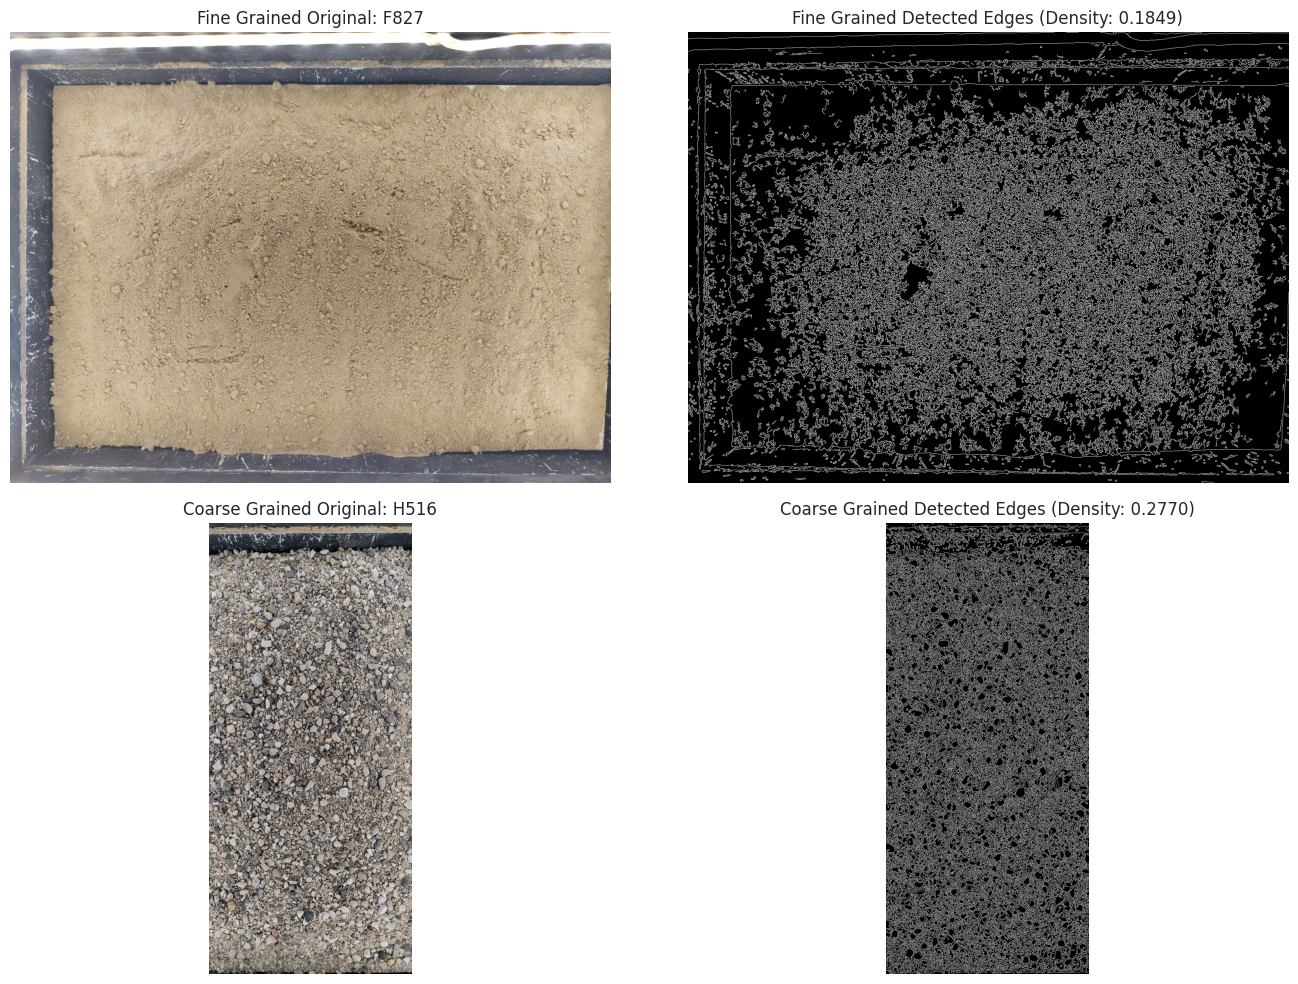

In [11]:
# Helper function to safely fetch image path (reusing our robust logic)
def get_image_path(sample_id):
    search_name = str(sample_id).lower()
    for root, _, files in os.walk(TRAIN_IMG_DIR):
        for file in files:
            if search_name in file.lower():
                return os.path.join(root, file)
    return None


# Pick two contrasting samples (e.g., one with fine grains and one with coarse grains)
# You can check your df_labels to find high/low variance samples, here we just pick two distinct ones
fine_sample_id = df_labels.sort_values(by="0.063", ascending=False).iloc[0][
    "sample_id"
]  # High amount of fine elements
coarse_sample_id = df_labels.sort_values(by="0.063", ascending=True).iloc[0][
    "sample_id"
]  # Low amount of fine elements (coarser)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (s_id, title_prefix) in enumerate(
    [(fine_sample_id, "Fine Grained"), (coarse_sample_id, "Coarse Grained")]
):
    path = get_image_path(s_id)
    if path:
        # Load and process image
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Apply Gaussian Blur and Canny Edge Detection
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        edges = cv2.Canny(blurred, 30, 100)

        # Plot Original
        axes[idx, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[idx, 0].axis("off")
        axes[idx, 0].set_title(f"{title_prefix} Original: {s_id}")

        # Plot Edges
        axes[idx, 1].imshow(edges, cmap="gray")
        axes[idx, 1].axis("off")
        axes[idx, 1].set_title(
            f"{title_prefix} Detected Edges (Density: {np.mean(edges > 0):.4f})"
        )

plt.tight_layout()
plt.show()

---

### 💡 Baseline Modeling Strategies & Insights

1. **Leveraging PPM (The Ultimate Hack):** Since different photos use different zoom levels and camera sensors, 100 pixels on one image does not equal 100 pixels on another. Before feeding images into a CNN (like `EfficientNet` or `ConvNeXt`), you should **resize them dynamically based on their PPM value**. This normalizes all images to a unified physical scale (e.g., fixed pixels per millimeter).
2. **Model Architecture Options:**
   * **Option A (Multi-output Regression CNN):** Use a pre-trained backbone, followed by a linear head with 11 outputs. Standard losses like **MSE** or **MAE** work fine, but consider adding a custom penalty to enforce *monotonicity* (since cumulative percentages must strictly increase).
   * **Option B (Feature Extraction + GBDT):** Extract statistical texture features (e.g., Haralick textures, local binary patterns, or CNN embeddings), merge them with the `ppm` tabular data, and train a **LightGBM / CatBoost** regressor.
3. **Validation Strategy:** Check for potential data leakage across device models. If certain phones only appear in the training or testing sets, a `GroupKFold` split based on camera/phone types is highly recommended to ensure robust local validation.